# Calidad del aire y salud respiratoria en la Región Metropolitana
## Informe hito 1 — Proyecto de Minería de Datos

### Grupo 5 · Región Metropolitana de Chile, 2020–2024

---

## 1. Introducción y motivación

La contaminación atmosférica es uno de los principales problemas de salud pública en zonas
urbanas (OMS, 2021). La Región Metropolitana (RM) de Santiago, debido a su geografía que atrapa los
contaminantes, un parque vehicular y residencial intensivo en combustión, e inversiones
térmicas invernales que disparan los niveles de material particulado, declara cada invierno
episodios de preemergencia y emergencia ambiental bajo el Plan de Prevención y Descontaminación
Atmosférica (MMA, 2017), y la intuición clínica asocia estos episodios con un aumento de las
consultas de urgencia respiratoria.

Este proyecto cuantifica esa relación con técnicas de minería de datos, integrando cinco
contaminantes monitoreados ($PM10$, $PM2.5$, $NO_2$, $O_3$, $SO_2$) con la demanda asistencial respiratoria de
toda la red de urgencia de la RM, considerando dos enfoques:

- **Sanitario / operativo:** Anticipar semanas de alta demanda permitiría planificar dotación,
  camas y campañas preventivas.
- **Epidemiológico:** Identificar qué contaminantes pesan más, con qué desfase temporal actúan, y
  si existen zonas de la ciudad con perfiles de riesgo diferenciados.

A diferencia de un análisis puramente correlacional, abordamos el problema con **aprendizaje
supervisado** (predicción de semanas de alto riesgo), **no supervisado** (segmentación de
establecimientos por perfil de enfermedad) y **selección de variables** (impacto relativo y efectos
rezagados de cada contaminante).

> **Referencias:**
> - Organización Mundial de la Salud (2021). *WHO global air quality guidelines: particulate matter (PM2.5 and PM10), ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide*. Ginebra: OMS.
> - Ministerio del Medio Ambiente de Chile (2017). *Plan de Prevención y Descontaminación Atmosférica para la Región Metropolitana de Santiago (PPDA)*. Decreto Supremo N° 31.


In [1]:
%%capture
# Carga de los cuatro datasets desde caché Parquet (definidos en exploration_optimized.ipynb)
%run exploration_optimized.ipynb

In [2]:
import matplotlib.dates as mdates
from scipy.stats import shapiro, kstest, probplot, spearmanr, kruskal
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.patheffects import withStroke

RESP_TOTAL = "TOTAL CAUSAS SISTEMA RESPIRATORIO"
age_cols = ["Menores_1", "De_1_a_4", "De_5_a_14", "De_15_a_64", "De_65_y_mas"]
print("Datasets disponibles:")
print(f"  df_air          : {df_air.shape}   ({df_air['time'].min().date()} -> {df_air['time'].max().date()})")
print(f"  df_urgencia_rm  : {df_urgencia_rm.shape}")
print(f"  df_hospitalaria_rm : {df_hospitalaria_rm.shape}")
print(f"  df_defunciones  : {df_defunciones.shape}")
print(f"  POLLUTANTS      : {POLLUTANTS}")

Datasets disponibles:
  df_air          : (426982, 10)   (2020-01-01 -> 2024-12-18)
  df_urgencia_rm  : (10259080, 14)
  df_hospitalaria_rm : (14333, 21)
  df_defunciones  : (649917, 27)
  POLLUTANTS      : ['mpm10', 'mpm25', 'no2', 'o3', 'so2']


---

## 2. Exploración de datos

Integramos **cuatro fuentes públicas** filtradas a la RM, 2020–2024. Las dos centrales del análisis
son **calidad del aire** (estaciones SINCA, frecuencia horaria) y **atenciones de urgencia** (red
asistencial, frecuencia diaria/semanal). Estadísticas hospitalarias y defunciones aportan contexto.

| Dataset | Fuente | Granularidad | Rol en el análisis |
|---|---|---|---|
| Calidad del aire | MinCiencia / SINCA | Horaria × estación | Variables predictoras (5 contaminantes) |
| Atenciones de urgencia | DEIS / MINSAL | Diaria × establecimiento × causa | Variable respuesta (demanda respiratoria) |
| Estadísticas hospitalarias | DEIS / MINSAL | Mensual × servicio | Contexto (ocupación de camas) |
| Defunciones | DEIS / MINSAL | Por evento | Contexto (mortalidad respiratoria) |

El reto de granularidad es claro: los contaminantes son **horarios y geolocalizados por estación**,
mientras que las urgencias son **diarias y por establecimiento**. La estrategia de fusión es
**agregar ambas series a frecuencia semanal** (promedio de estaciones × suma de urgencias) e indexar
por `(año, semana ISO)`.


In [3]:
# Resumen estadístico compacto de las dos fuentes centrales
print("="*64); print("CALIDAD DEL AIRE — df_air (estaciones RM, 2020–2024)"); print("="*64)
display(df_air[POLLUTANTS].describe().round(1).T[["mean", "std", "min", "50%", "max"]])

print("\n" + "="*64); print("URGENCIAS — df_urgencia_rm (RM, 2020–2024)"); print("="*64)
print(f"Establecimientos: {df_urgencia_rm['NEstablecimiento'].nunique()}   |   "
      f"Causas distintas: {df_urgencia_rm['GlosaCausa'].nunique()}   |   "
      f"Estaciones de aire: {df_air['nombreEstacion'].nunique()}")
resp_total_yr = (df_urgencia_rm[df_urgencia_rm['GlosaCausa'] == RESP_TOTAL]
                 .assign(año=lambda d: pd.to_datetime(d['fecha'], dayfirst=True).dt.year)
                 .groupby('año')['Total'].sum())
print("\nTotal atenciones respiratorias por año:")
display(resp_total_yr.to_frame('atenciones'))

CALIDAD DEL AIRE — df_air (estaciones RM, 2020–2024)


,mean,std,min,50%,max
mpm10,58.3,44.0,1.0,50.0,718.0
mpm25,22.1,21.4,0.0,16.0,379.0
no2,20.5,15.0,0.1,17.8,167.4
o3,11.6,15.4,0.1,3.1,140.8
so2,2.0,0.9,0.4,2.1,16.8



URGENCIAS — df_urgencia_rm (RM, 2020–2024)


Establecimientos: 158   |   Causas distintas: 44   |   Estaciones de aire: 12



Total atenciones respiratorias por año:


,atenciones
año,
2020,447302
2021,472426
2022,1509971
2023,1771188
2024,1771316


### 2.1 Estacionalidad de los contaminantes

El mapa de calor muestra el nivel medio de cada contaminante por estación de monitoreo y mes. 
Se observa que el material particulado (PM10, PM2.5) y el NO₂ se concentran en los meses
fríos (mayo–agosto), cuando la inversión térmica atrapa las emisiones. El O₃, en cambio, es
fotoquímico y de verano.


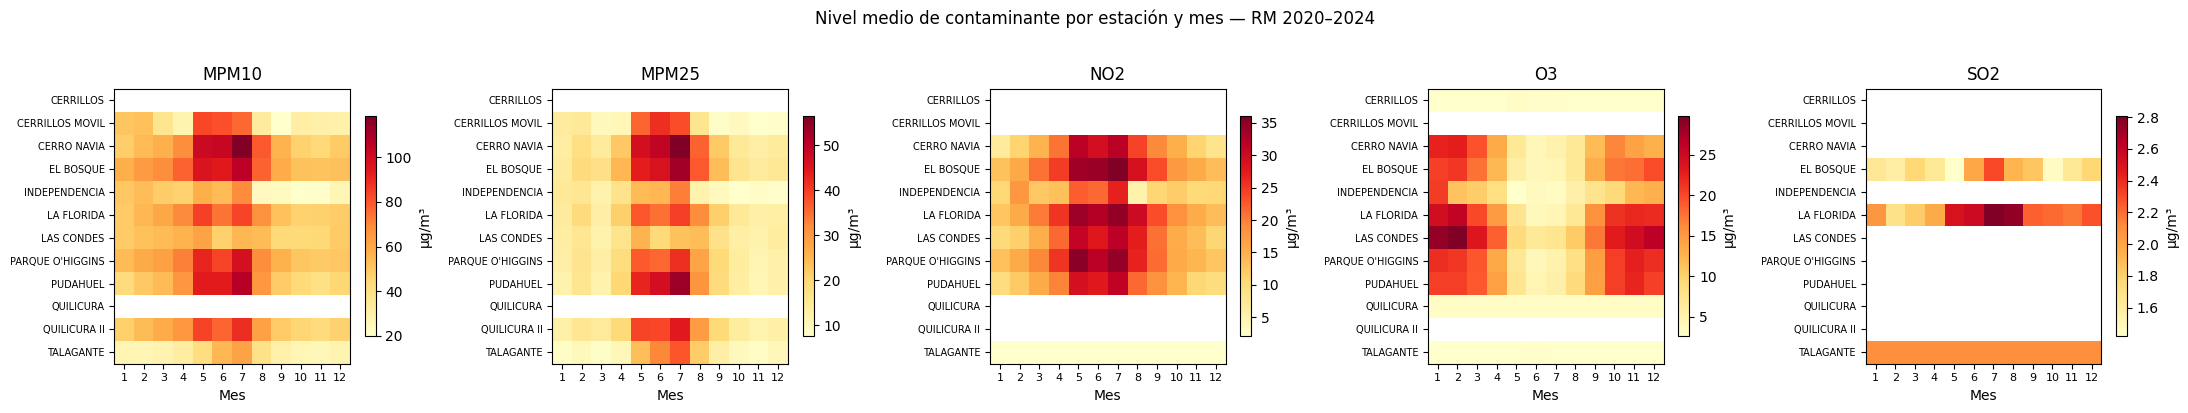

In [4]:
df_air_m = df_air.copy()
df_air_m["month"] = df_air_m["time"].dt.month
stations_sorted = sorted(df_air["nombreEstacion"].unique())

fig, axes = plt.subplots(1, len(POLLUTANTS), figsize=(22, 4))
for ax, pol in zip(axes, POLLUTANTS):
    pivot = (df_air_m.groupby(["nombreEstacion", "month"])[pol].mean()
             .unstack(fill_value=np.nan).reindex(stations_sorted))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(12)); ax.set_xticklabels(range(1, 13), fontsize=8)
    ax.set_yticks(range(len(stations_sorted))); ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(pol.upper()); ax.set_xlabel("Mes")
    plt.colorbar(im, ax=ax, shrink=0.8, label="µg/m³")
fig.suptitle("Nivel medio de contaminante por estación y mes — RM 2020–2024", y=1.02)
plt.tight_layout(); plt.show()

### 2.2 Demanda de urgencia respiratoria

La serie semanal de atenciones respiratorias muestra picos invernales pronunciados y recurrentes
cada año. Sin embargo, el nivel base no es estacionario: el volumen anual de atenciones
respiratorias sufre un alza de ~3× entre 2020–2021 y 2022–2024 (≈447 k y 472 k atenciones en 2020 y
2021, frente a ≈1.51 M, 1.77 M y 1.77 M en 2022–2024). La caída de 2020–2021 es coherente con el
confinamiento COVID-19 (menos consultas presenciales y desplome de las infecciones respiratorias
estacionales por mascarilla y distanciamiento), pero es un cambio de régimen, no un simple
rebote. Como se discute en **5.4**, este desnivel inter-anual condiciona la definición del *target*
supervisado de P1 y debe tenerse presente al interpretar su desempeño.


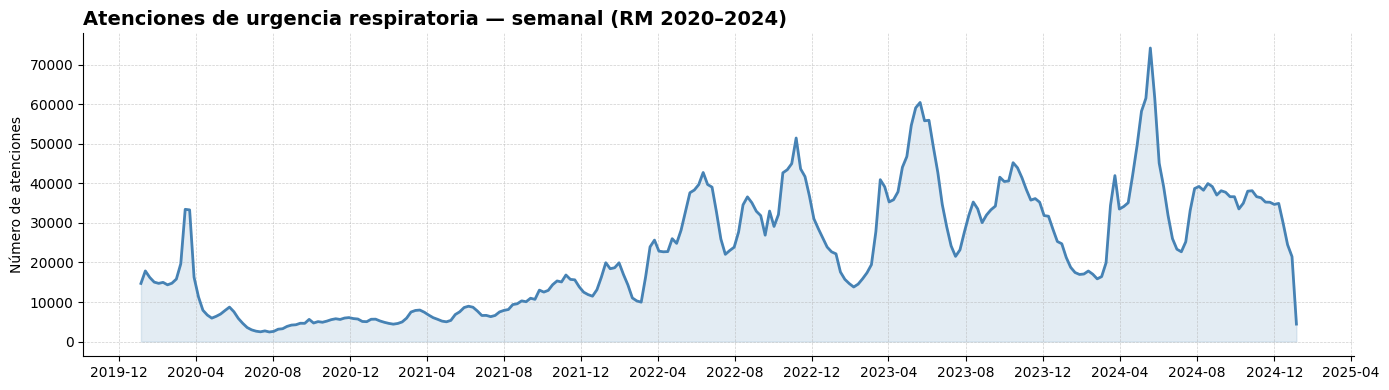

In [5]:
resp_w_ts = (df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL].copy()
             .assign(fecha_dt=lambda d: pd.to_datetime(d["fecha"], dayfirst=True))
             .groupby(pd.Grouper(key="fecha_dt", freq="W"))["Total"].sum().sort_index())
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(resp_w_ts.index, resp_w_ts.values, linewidth=2, color="steelblue")
ax.fill_between(resp_w_ts.index, resp_w_ts.values, alpha=0.15, color="steelblue")
ax.set_title("Atenciones de urgencia respiratoria — semanal (RM 2020–2024)",
             fontsize=14, fontweight="bold", loc="left")
ax.set_ylabel("Número de atenciones")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

### 2.3 Co-estacionalidad contaminación–salud

Superponiendo el ciclo anual medio de material particulado y de urgencias respiratorias, ambas
curvas alcanzan su peak máximo en pleno invierno. Esta co-estacionalidad es el punto de partida de
nuestras preguntas: ¿es solo coincidencia estacional, o hay señal aprovechable para predecir y
para distinguir el aporte de cada contaminante?


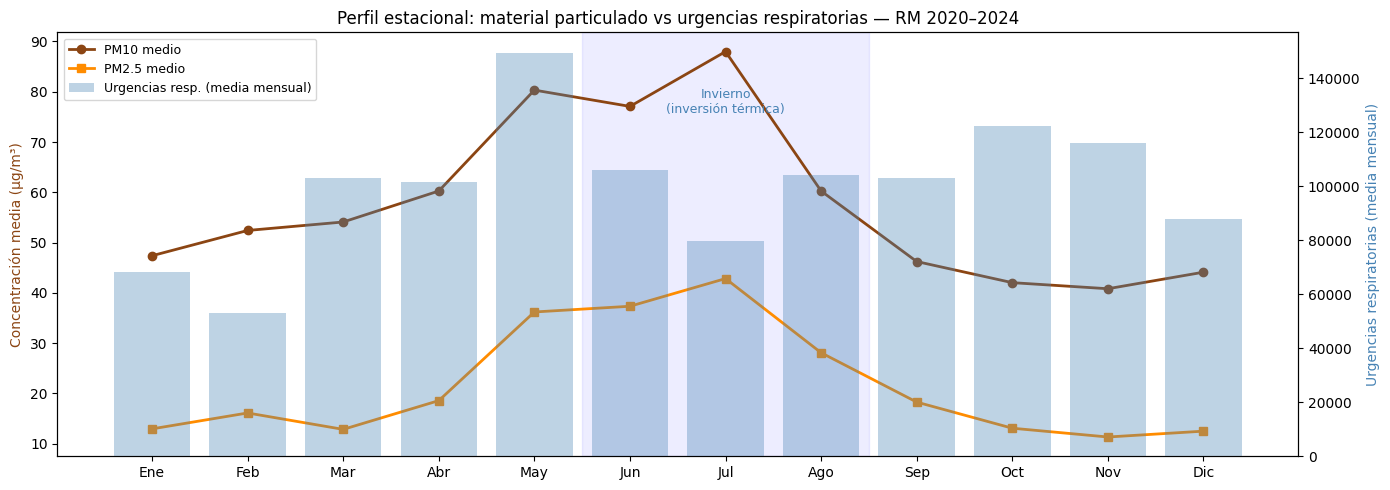

In [6]:
air_monthly_df = df_air.copy(); air_monthly_df["month"] = air_monthly_df["time"].dt.month
pm_monthly = air_monthly_df.groupby("month")[["mpm10", "mpm25"]].mean()

resp_m = df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL].copy()
resp_m["date"] = pd.to_datetime(resp_m["fecha"], dayfirst=True)
resp_m["month"] = resp_m["date"].dt.month; resp_m["year"] = resp_m["date"].dt.year
resp_monthly = resp_m.groupby(["year", "month"])["Total"].sum().groupby("month").mean()

months = list(range(1, 13))
month_labels = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
fig, ax1 = plt.subplots(figsize=(14, 5)); ax2 = ax1.twinx()
ax1.plot(months, pm_monthly["mpm10"].reindex(months), "o-", color="saddlebrown", lw=2, label="PM10 medio")
ax1.plot(months, pm_monthly["mpm25"].reindex(months), "s-", color="darkorange", lw=2, label="PM2.5 medio")
ax2.bar(months, resp_monthly.reindex(months), color="steelblue", alpha=0.35, label="Urgencias resp. (media mensual)")
ax1.set_xticks(months); ax1.set_xticklabels(month_labels)
ax1.set_ylabel("Concentración media (µg/m³)", color="saddlebrown")
ax2.set_ylabel("Urgencias respiratorias (media mensual)", color="steelblue")
ax1.set_title("Perfil estacional: material particulado vs urgencias respiratorias — RM 2020–2024")
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, fontsize=9, loc="upper left")
ax1.axvspan(5.5, 8.5, alpha=0.07, color="blue")
ax1.text(7, ax1.get_ylim()[1]*0.88, "Invierno\n(inversión térmica)", ha="center", fontsize=9, color="steelblue", va="top")
plt.tight_layout(); plt.show()

### 2.4 Estructura entre contaminantes (multicolinealidad)

Antes de modelar conviene revisar cómo se relacionan los contaminantes entre sí, se considera utilizar la correlación de
Spearman (por la falta de normalidad en los datos),se observan los siguientes resultados: PM10–PM2.5 están fuertemente correlacionados (combustión/tráfico),
mientras O₃ se separa del resto (fotoquímico). Esta multicolinealidad justifica usar técnicas de
selección de variables y reducción de dimensión.


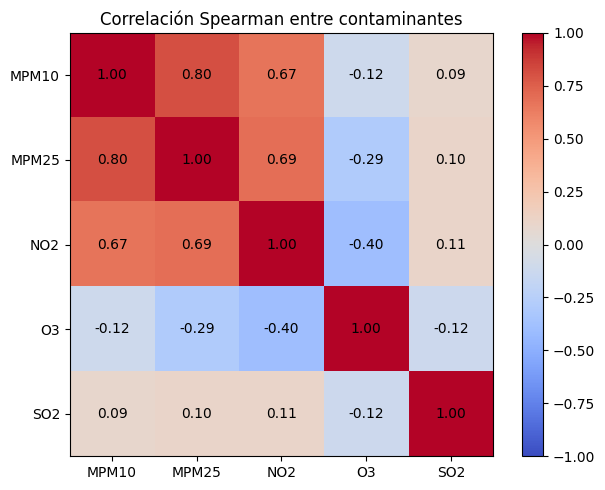

In [7]:
spearman_r = df_air[POLLUTANTS].corr(method="spearman")
labels = [p.upper() for p in POLLUTANTS]
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(spearman_r.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(POLLUTANTS)), labels=labels)
ax.set_yticks(range(len(POLLUTANTS)), labels=labels)
for i in range(len(POLLUTANTS)):
    for j in range(len(POLLUTANTS)):
        ax.text(j, i, f"{spearman_r.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax); ax.set_title("Correlación Spearman entre contaminantes")
plt.tight_layout(); plt.show()

### 2.5 Distribución espacial por comuna

> **Volúmenes absolutos, no incidencia.** El choropleth muestra el número total de atenciones,
> no una tasa por habitante. Las comunas que aparecen más oscuras son, en gran medida, las que
> concentran población y los grandes hospitales de referencia (Santiago, Maipú, Puente Alto), no
> necesariamente las más expuestas a contaminación. La normalización por población es un paso
> explícito del Hito 2 (ver **5.4**).

Aprovechando el shapefile de comunas (`data/Comunas/`), proyectamos las urgencias respiratorias
acumuladas 2020–2024 a nivel comunal. Como `df_urgencia_rm` no trae la comuna, atribuimos cada
atención vía el catálogo de establecimientos (`df_estab_rm`, columna `ComunaGlosa`). Sobre el mapa
se superponen las estaciones de monitoreo de calidad del aire, que evidencian dos limitaciones
para el análisis espacial:

- El volumen asistencial confunde efecto de contaminación con tamaño poblacional y catchment
  hospitalario (área de responsabilidad territorial del hospital). Una comuna con un hospital de alta complejidad atrae pacientes de fuera de su
  territorio, sobreestimando su "carga local".
- Cobertura desigual de la red SINCA: hay comunas pobladas sin estación cercana, lo que
  introduce error de medición al asignar exposición por estación más próxima.

Ambas son razones por las que la asociación PM10 - tasa respiratoria a nivel establecimiento es
débil (lo veremos en P2 en el Hito 2) y motivan normalizar por población comunal e incorporar
distancia ponderada a las estaciones como mejoras prioritarias.


Comunas RM en shapefile: 52   |   con datos de urgencia: 50


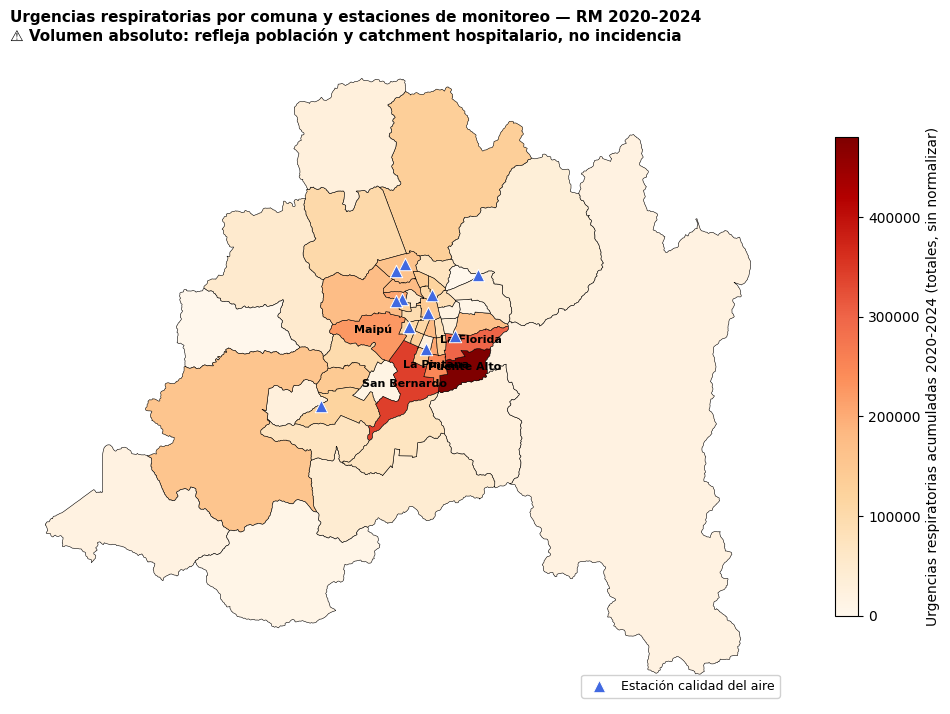


Top 10 comunas por urgencias respiratorias 2020-2024:


,comuna,resp_total
0,Puente Alto,"480,224"
1,San Bernardo,"343,029"
2,La Florida,"298,295"
3,La Pintana,"248,119"
4,Maipú,"226,818"
5,Cerro Navia,"207,610"
6,San Ramón,"206,030"
7,Renca,"177,374"
8,San Miguel,"177,344"
9,Pudahuel,"174,997"


In [8]:
import geopandas as gpd

# 1) Cargar comunas y filtrar RM (codregion=13). Reproyectar a WGS84 para alinear con lat/lon.
gdf_comunas = gpd.read_file("data/Comunas/comunas.shp")
gdf_rm = gdf_comunas[gdf_comunas["codregion"] == 13].to_crs(epsg=4326).copy()

# 2) Atribuir comuna a cada urgencia via df_estab_rm (catálogo de establecimientos)
estab_to_comuna = df_estab_rm.set_index("id")["ComunaGlosa"].to_dict()
resp_by_comuna = (
    df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL]
    .assign(comuna=lambda x: x["IdEstablecimiento"].str.strip().map(estab_to_comuna))
    .dropna(subset=["comuna"])
    .groupby("comuna")["Total"].sum()
    .reset_index(name="resp_total")
)

# 3) Merge shapefile (Comuna) ↔ agregación (comuna)
gdf_map = gdf_rm.merge(resp_by_comuna, left_on="Comuna", right_on="comuna", how="left")
gdf_map["resp_total"] = gdf_map["resp_total"].fillna(0)
print(f"Comunas RM en shapefile: {len(gdf_rm)}   |   con datos de urgencia: {(gdf_map['resp_total']>0).sum()}")

# 4) Estaciones de monitoreo (centroides lat/lon)
station_geo = df_air.groupby("nombreEstacion")[["latitud", "longitud"]].mean().reset_index()

# 5) Choropleth + overlay de estaciones
fig, ax = plt.subplots(figsize=(10, 9))
gdf_map.plot(
    column="resp_total", cmap="OrRd", linewidth=0.4, edgecolor="black",
    legend=True, ax=ax,
    legend_kwds={"label": "Urgencias respiratorias acumuladas 2020-2024 (totales, sin normalizar)", "shrink": 0.55},
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "linewidth": 0.4, "label": "Sin datos"},
)
ax.scatter(station_geo["longitud"], station_geo["latitud"],
           s=80, c="royalblue", marker="^", edgecolors="white", linewidths=0.7,
           label="Estación calidad del aire", zorder=5)

# Etiquetar las 5 comunas con mayor volumen
for _, row in gdf_map.nlargest(5, "resp_total").iterrows():
    c = row.geometry.centroid
    ax.annotate(row["Comuna"], (c.x, c.y), fontsize=8, ha="center", fontweight="bold")

ax.set_title("Urgencias respiratorias por comuna y estaciones de monitoreo — RM 2020–2024\n⚠ Volumen absoluto: refleja población y catchment hospitalario, no incidencia",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout(); plt.show()

# Top 10 comunas por volumen (tabla complementaria)
print("\nTop 10 comunas por urgencias respiratorias 2020-2024:")
display(
    resp_by_comuna.sort_values("resp_total", ascending=False)
    .head(10).reset_index(drop=True)
    .style.format({"resp_total": "{:,.0f}"})
)


---

## 3. Preguntas y problemas

A partir de la exploración formulamos tres preguntas que requieren aprendizaje automático
(no se responden con una simple correlación) y cubren aprendizaje supervisado, no supervisado y
selección de variables.

### P1 — Predicción de semanas de alto riesgo sanitario · *(supervisado, clasificación)*
> **¿Es posible predecir si una semana será de _alto riesgo_ (demanda de urgencias respiratorias por
> sobre la mediana) a partir de los niveles semanales de PM10, PM2.5, NO₂, O₃ y SO₂?**

*Hipótesis:* los contaminantes contienen señal suficiente para clasificar semanas de alto riesgo por
encima del azar (F1 macro > 0.5), siendo NO₂ y material particulado los predictores más informativos.

### P2 — Segmentación territorial por perfil de enfermedad · *(no supervisado, clustering)*
> **¿Existen grupos de establecimientos de salud de la RM con perfiles de morbilidad respiratoria
> similares, y esos grupos se asocian a distintos niveles de exposición a PM10?**

*Hipótesis:* emergen grupos diferenciables por perfil de causas, su alineación con la exposición a
PM10 es, sin embargo, débil, porque el perfil de morbilidad depende también del tipo de
establecimiento y la población de su área de influencia.

### P3 — Impacto relativo y efectos rezagados · *(selección de variables / feature engineering)*
> **¿Qué contaminantes tienen mayor impacto relativo sobre las urgencias respiratorias y existe un
> desfase temporal (lag) óptimo entre la exposición y la respuesta sanitaria?**

*Hipótesis:* el efecto no es instantáneo, la exposición a partículas se traduce en consultas con un
rezago de 2–3 semanas (inflamación → agudización → consulta), y la Mutual Information ordena los
contaminantes de forma distinta a la correlación lineal por la presencia de efectos no lineales.


---

## 4. Propuesta metodológica experimental

| Pregunta | Preprocesamiento | Modelos / técnicas | Métricas de evaluación |
|---|---|---|---|
| **P1** (clasif.) | Series semanales `(año, semana)`; imputación por media; etiqueta binaria *alto riesgo* = urgencias > mediana; `StandardScaler`; split 70/30 estratificado | Regresión Logística y Árbol de Decisión (`GridSearchCV`); comparación con baseline aleatorio | F1 macro (clases balanceadas), CV 5-fold, matriz de confusión, importancia de variables |
| **P2** (clustering) | Perfil de causas por establecimiento normalizado a proporciones; `StandardScaler` + PCA; método del codo para *k* | K-Means; contraste de PM10 entre clusters | Inercia (codo), Kruskal-Wallis de PM10 entre grupos, interpretación cualitativa de perfiles |
| **P3** (selección) | Mismas series semanales; *shift* de la respuesta para lags 0–4 semanas | Mutual Information (no lineal) + correlación cruzada rezagada de Spearman | Ranking MI, r de Spearman por lag, lag óptimo por contaminante |

**Justificación de decisiones clave:**

- **Frecuencia semanal:** suaviza el ruido diario y resuelve el desajuste de granularidad
  aire (horario) - urgencias (diario), conservando la dinámica estacional.
- **Métodos no paramétricos (Spearman, Kruskal-Wallis, MI):** los contaminantes no son normales
  (se verifica en **5.1**), lo que invalida Pearson/ANOVA.
- **F1 macro y no *accuracy*:** aunque construimos las clases balanceadas por la mediana, F1 macro es
  robusta y comparable entre modelos.
- **Comparar dos modelos supervisados:** un modelo lineal (Regresión Logística) frente a uno no lineal
  e interpretable (Árbol), para contrastar sesgo/varianza y legibilidad.


---

## 5. Experimento preliminar

Implementamos completo el experimento de P1 (clasificación de semanas de alto riesgo),
precedido por el análisis de soporte de P3 (normalidad, asociación e impacto relativo) que motiva la
selección de variables.

### 5.1 Test de normalidad — ¿por qué métodos no paramétricos?

Shapiro-Wilk y Kolmogorov-Smirnov sobre cada contaminante: **todos rechazan la normalidad**
(p ≪ 0.05). Los Q-Q plots confirman las colas pesadas. Esto fundamenta el uso de Spearman, KW y MI.


Contaminante | SW p-val     | KS p-val     | Veredicto
--------------------------------------------------------


MPM10        | 2.6713e-53   | 0.0000e+00   | No normal ✗
MPM25        | 2.5190e-65   | 0.0000e+00   | No normal ✗
NO2          | 3.3561e-46   | 0.0000e+00   | No normal ✗
O3           | 1.5158e-68   | 0.0000e+00   | No normal ✗
SO2          | 3.3422e-57   | 0.0000e+00   | No normal ✗


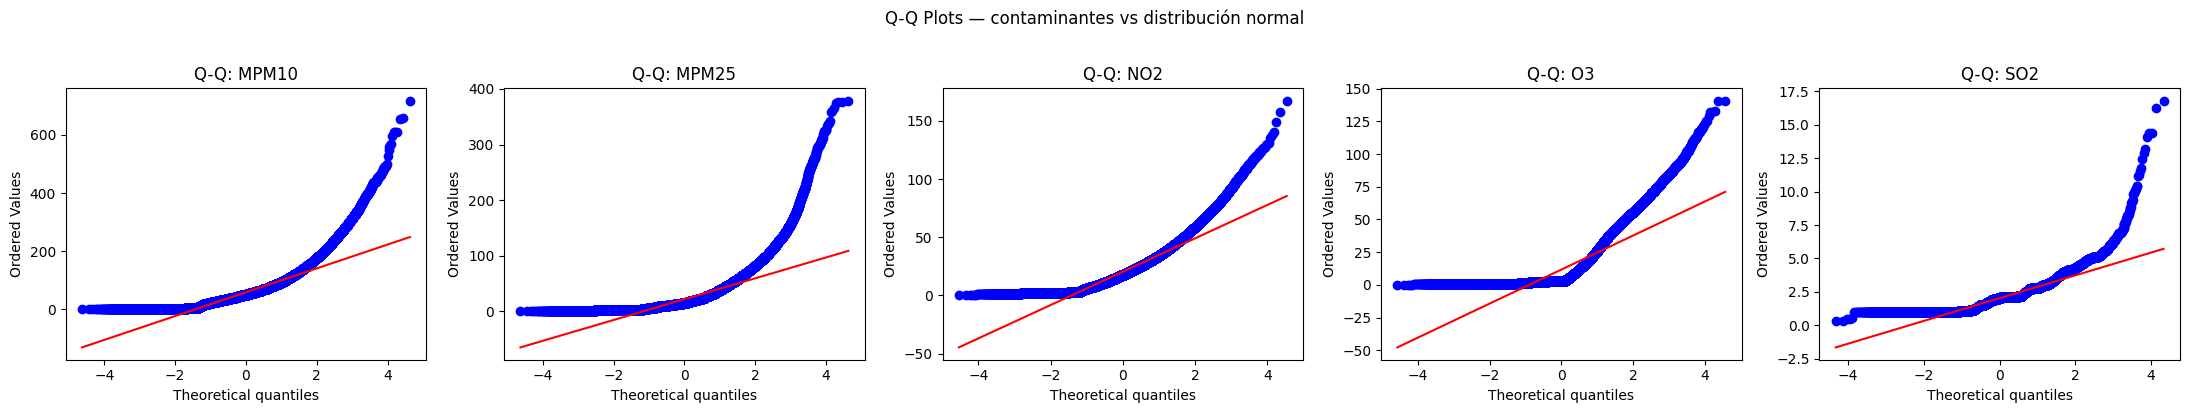

In [9]:
print(f"{'Contaminante':12} | {'SW p-val':12} | {'KS p-val':12} | Veredicto")
print("-" * 56)
for pol in POLLUTANTS:
    vals = df_air[pol].dropna()
    sample = vals.sample(min(5000, len(vals)), random_state=42)
    _, sw_p = shapiro(sample)
    _, ks_p = kstest((vals - vals.mean()) / vals.std(), "norm")
    verdict = "Normal" if (sw_p > 0.05 and ks_p > 0.05) else "No normal ✗"
    print(f"{pol.upper():12} | {sw_p:.4e}   | {ks_p:.4e}   | {verdict}")

fig, axes = plt.subplots(1, len(POLLUTANTS), figsize=(22, 4))
for ax, pol in zip(axes, POLLUTANTS):
    probplot(df_air[pol].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q: {pol.upper()}"); ax.lines[-1].set_color("red")
plt.suptitle("Q-Q Plots — contaminantes vs distribución normal", y=1.02)
plt.tight_layout(); plt.show()

### 5.2 Asociación contaminante - urgencias e impacto relativo (P3)

Construimos las series semanales alineadas (`p1_df`). La correlación de Spearman en ventana
contemporánea (lag 0) muestra señal significativa de **NO₂** (r = +0.27, p < 0.001) y **SO₂**
(r = +0.16, p < 0.05); PM10, PM2.5 y O₃ no alcanzan significancia. La Mutual Information
que capta no linealidades, reordena el ranking:

| Contaminante | MI | Spearman r (lag 0) |
|---|---|---|
| O₃ | 0.412 | +0.02 (n.s.) |
| SO₂ | 0.314 | +0.16 (*) |
| NO₂ | 0.142 | +0.27 (***) |
| PM2.5 | 0.128 | +0.07 (n.s.) |
| PM10 | 0.044 | +0.11 (n.s.) |

O₃ encabeza la MI pese a su correlación lineal nula, lo que podría indicar un efecto no
lineal/umbral. 

**Observaciones:** 
 * Con n = 261 semanas el estimador de MI es ruidoso, por lo que el ranking es exploratorio.
 * O₃ y NO₂ presentan además una tendencia inter-anual (NO₂ sube de ~17 a ~23 µg/m³ entre 2020 y 2024; O₃ salta en 2023–2024) que coincide con el cambio de régimen de las urgencias, por lo que parte de su «impacto» puede ser un *proxy del año* más que un efecto agudo (ver **5.4**).


Semanas alineadas: 261

Contaminante | Spearman r   | p-valor      | Sig.
----------------------------------------------------
MPM10        | +0.1119     | 7.1045e-02   | n.s.
MPM25        | +0.0749     | 2.2764e-01   | n.s.
NO2          | +0.2681     | 1.1295e-05   | ***
O3           | +0.0227     | 7.1495e-01   | n.s.
SO2          | +0.1576     | 1.0787e-02   | *


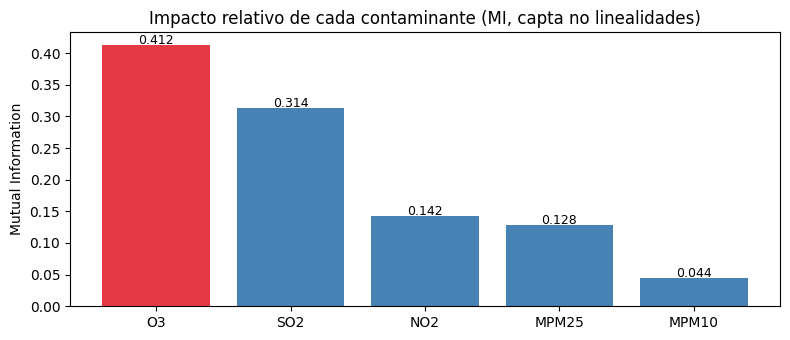

In [10]:
# --- Series semanales alineadas: contaminantes (media) + urgencias respiratorias (suma) ---
air_w = df_air.copy()
air_w["year"] = air_w["time"].dt.year
air_w["week"] = air_w["time"].dt.isocalendar().week.astype(int)
air_weekly = air_w.groupby(["year", "week"])[POLLUTANTS].mean()

resp_w = df_urgencia_rm[df_urgencia_rm["GlosaCausa"] == RESP_TOTAL].copy()
resp_w["year"] = pd.to_datetime(resp_w["fecha"], dayfirst=True).dt.year
resp_weekly = resp_w.groupby(["year", "semana"])["Total"].sum()
resp_weekly.index.names = ["year", "week"]

p1_df = air_weekly.join(resp_weekly.rename("resp"), how="inner").dropna(subset=["resp"])
p1_df[POLLUTANTS] = p1_df[POLLUTANTS].fillna(p1_df[POLLUTANTS].mean())
print(f"Semanas alineadas: {len(p1_df)}")

# --- Spearman lag 0 ---
print(f"\n{'Contaminante':12} | {'Spearman r':12} | {'p-valor':12} | Sig.")
print("-" * 52)
for pol in POLLUTANTS:
    r, p = spearmanr(p1_df[pol], p1_df["resp"])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"{pol.upper():12} | {r:+.4f}     | {p:.4e}   | {sig}")

# --- Mutual Information ---
mi_scores = mutual_info_regression(p1_df[POLLUTANTS], p1_df["resp"], random_state=42)
mi_series = pd.Series(mi_scores, index=POLLUTANTS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar([p.upper() for p in mi_series.index], mi_series.values,
              color=["#e63946" if v == mi_series.max() else "steelblue" for v in mi_series.values])
ax.set_ylabel("Mutual Information"); ax.set_title("Impacto relativo de cada contaminante (MI, capta no linealidades)")
for bar, val in zip(bars, mi_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### 5.3 Clasificación de semanas de alto riesgo (P1)

**Preparación:** etiqueta binaria *alto riesgo* = urgencias semanales sobre la mediana (clases
balanceadas 50/50), variables = los cinco contaminantes estandarizados, split 70/30 estratificado.


In [11]:
weekly_cls = p1_df.copy()
weekly_cls["alto_riesgo"] = (weekly_cls["resp"] > weekly_cls["resp"].median()).astype(int)
X_cls, y_cls = weekly_cls[POLLUTANTS], weekly_cls["alto_riesgo"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.3, stratify=y_cls, random_state=42)
scaler_cls = StandardScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_test_sc  = scaler_cls.transform(X_test)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Total semanas : {len(weekly_cls)}   |   Train/Test: {len(X_train)}/{len(X_test)}")
print(f"Balance clases: {y_cls.value_counts().to_dict()}  (0=Bajo, 1=Alto)")

Total semanas : 261   |   Train/Test: 182/79
Balance clases: {0: 131, 1: 130}  (0=Bajo, 1=Alto)


**Modelo 1 — Regresión Logística** (lineal, interpretable por signo del coeficiente):

=== Regresión Logística — Test Set ===


              precision    recall  f1-score   support

        Bajo       0.59      0.65      0.62        40
        Alto       0.60      0.54      0.57        39

    accuracy                           0.59        79
   macro avg       0.60      0.59      0.59        79
weighted avg       0.60      0.59      0.59        79

CV F1 macro (5-fold): 0.712 ± 0.039


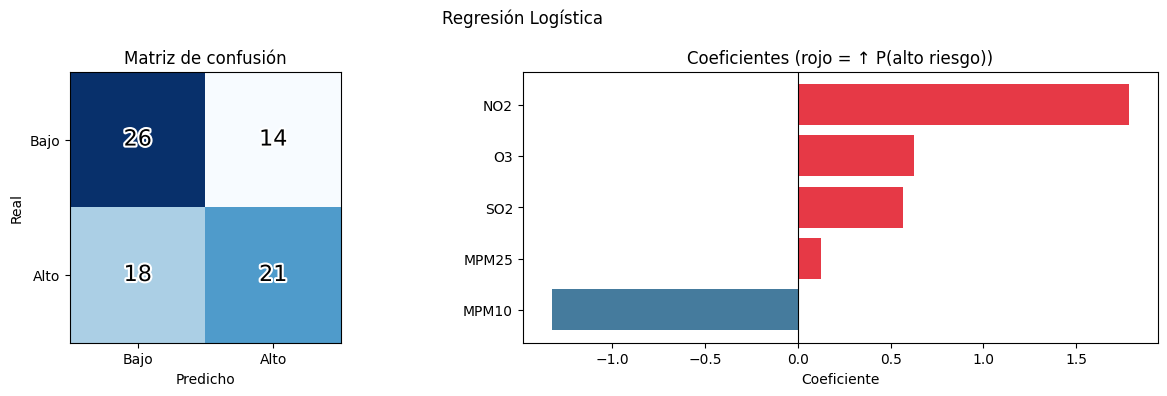

In [12]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print("=== Regresión Logística — Test Set ===")
print(classification_report(y_test, y_pred_lr, target_names=["Bajo", "Alto"]))
cv_lr = cross_val_score(lr, scaler_cls.fit_transform(X_cls), y_cls, cv=cv5, scoring="f1_macro")
print(f"CV F1 macro (5-fold): {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
im = axes[0].imshow(cm_lr, cmap="Blues")
axes[0].set_xticks([0, 1], labels=["Bajo", "Alto"]); axes[0].set_yticks([0, 1], labels=["Bajo", "Alto"])
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real"); axes[0].set_title("Matriz de confusión")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_lr[i, j], ha="center", va="center", fontsize=16,
                     color="black",
                     path_effects=[withStroke(linewidth=3, foreground="white")])
coef = pd.Series(lr.coef_[0], index=[p.upper() for p in POLLUTANTS]).sort_values()
axes[1].barh(coef.index, coef.values, color=["#e63946" if v > 0 else "#457b9d" for v in coef.values])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Coeficientes (rojo = ↑ P(alto riesgo))"); axes[1].set_xlabel("Coeficiente")
plt.suptitle("Regresión Logística"); plt.tight_layout(); plt.show()

**Modelo 2 — Árbol de Decisión** con búsqueda de hiperparámetros (`GridSearchCV`, no lineal):

Mejores parámetros : {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 6}
Mejor CV F1 macro  : 0.703

=== Árbol de Decisión — Test Set ===
              precision    recall  f1-score   support

        Bajo       0.65      0.65      0.65        40
        Alto       0.64      0.64      0.64        39

    accuracy                           0.65        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.65      0.65      0.65        79



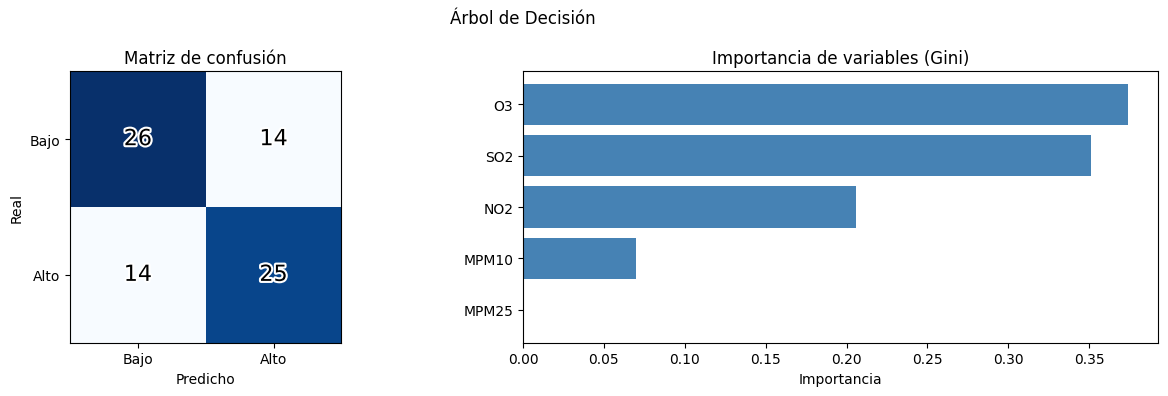

In [13]:
param_grid = {"criterion": ["gini", "entropy"], "max_depth": [2, 3, 4, 5, None], "min_samples_leaf": [2, 4, 6]}
gs = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=42),
                  param_grid, cv=cv5, scoring="f1_macro", n_jobs=-1)
gs.fit(X_cls, y_cls)
print(f"Mejores parámetros : {gs.best_params_}")
print(f"Mejor CV F1 macro  : {gs.best_score_:.3f}")

best_dt = gs.best_estimator_
best_dt.fit(X_train_sc, y_train)
y_pred_dt = best_dt.predict(X_test_sc)
print("\n=== Árbol de Decisión — Test Set ===")
print(classification_report(y_test, y_pred_dt, target_names=["Bajo", "Alto"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
im = axes[0].imshow(cm_dt, cmap="Blues")
axes[0].set_xticks([0, 1], labels=["Bajo", "Alto"]); axes[0].set_yticks([0, 1], labels=["Bajo", "Alto"])
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real"); axes[0].set_title("Matriz de confusión")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_dt[i, j], ha="center", va="center", fontsize=16,
                     color="black",
                     path_effects=[withStroke(linewidth=3, foreground="white")])
imp = pd.Series(best_dt.feature_importances_, index=[p.upper() for p in POLLUTANTS]).sort_values()
axes[1].barh(imp.index, imp.values, color="steelblue")
axes[1].set_title("Importancia de variables (Gini)"); axes[1].set_xlabel("Importancia")
plt.suptitle("Árbol de Decisión"); plt.tight_layout(); plt.show()

**Comparación de modelos** (F1 macro, validación cruzada 5-fold):

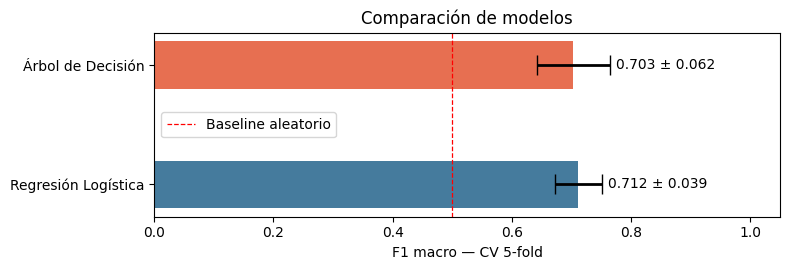

In [14]:
X_sc_all = scaler_cls.fit_transform(X_cls)
model_scores = {
    "Regresión Logística": cross_val_score(
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        X_sc_all, y_cls, cv=cv5, scoring="f1_macro"),
    "Árbol de Decisión": cross_val_score(gs.best_estimator_, X_sc_all, y_cls, cv=cv5, scoring="f1_macro"),
}
fig, ax = plt.subplots(figsize=(8, 2.8))
names = list(model_scores.keys())
means = [s.mean() for s in model_scores.values()]; stds = [s.std() for s in model_scores.values()]
bars = ax.barh(names, means, xerr=stds, color=["#457b9d", "#e76f51"], capsize=7, height=0.4,
               error_kw={"linewidth": 2})
ax.set_xlabel("F1 macro — CV 5-fold"); ax.set_title("Comparación de modelos"); ax.set_xlim(0, 1.05)
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.9, label="Baseline aleatorio")
for bar, m, s in zip(bars, means, stds):
    ax.text(m + s + 0.01, bar.get_y() + bar.get_height()/2, f"{m:.3f} ± {s:.3f}", va="center", fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()

### 5.4 Análisis de resultados y ajustes para el Hito 2

**Desempeño:** En validación cruzada ambos modelos superan el baseline aleatorio
(F1 macro: Regresión Logística 0.712 ± 0.039, Árbol 0.703 ± 0.062, frente a 0.50). En el conjunto
de test (held-out 30 %) el desempeño es más modesto y la jerarquía se invierte: **Árbol F1 = 0.65**
frente a **Regresión Logística F1 = 0.59** (apenas sobre el baseline). La Regresión Logística es
más estable entre folds (menor varianza), pero no es la mejor fuera de muestra; la brecha
CV → test (0.71 → 0.59 en la lineal) refleja el optimismo propio de n = 261. NO₂ y O₃ son las
variables más informativas, coherente con el ranking de MI (la hipótesis de P1 acertó en NO₂, pero el
segundo predictor fue O₃, no el material particulado).

> #### Confusión temporal del *target* (hallazgo crítico)
> El target «alto riesgo» = semana sobre la mediana 2020–2024 queda dominado por el cambio de
> régimen documentado en **2.2**: casi todas las semanas de 2020–2021 caen bajo la mediana y casi todas
> las de 2022–2024 sobre ella.
>
> | Año | Semanas «Bajo» | Semanas «Alto» |
> |---|---|---|
> | 2020 | 49 | 4 |
> | 2021 | 48 | 5 |
> | 2022 | 17 | 35 |
> | 2023 | 9 | 43 |
> | 2024 | 8 | 44 |
>
> Es decir, clasificar alto riesgo equivale en gran medida a distinguir 2020–21 de 2022–24. Y los
> dos predictores más informativos, NO₂ y O₃, son justamente los que tienen tendencia inter-anual
> creciente, por lo que actúan como proxy del año. Gran parte del F1 ≈ 0.71 refleja esta
> discontinuidad temporal (efecto COVID y/o cobertura de datos), no una respuesta aguda
> contaminación - salud. El resultado es, por tanto, un **límite superior optimista**.

**Ajustes previstos para el Hito 2:**
1. Redefinir el *target* para neutralizar el régimen inter-anual: etiquetar respecto a una mediana
   estacional / intra-año (o estandarizar las urgencias por año), de modo que alto riesgo mida la
   desviación respecto al nivel esperado de esa temporada y no el año calendario; verificar si la señal
   de contaminación sobrevive.
2. Comprobar si el desnivel 2020–2021 es epidemiología real (COVID) o un artefacto de cobertura
   del filtro RM (IDs de establecimientos derivados del archivo 2023) y, si procede, normalizar la
   demanda por población.
3. Incorporar variables rezagadas (lags 2–3 semanas, P3) y términos estacionales explícitos para
   separar la señal de contaminación de la estacionalidad compartida.
4. Completar P2 (clustering K-Means) con nombres interpretables de los clusters y el contraste de
   PM10 entre grupos.
5. Añadir controles meteorológicos (temperatura) y un diseño cuasi-experimental (umbrales
   normativos) para acercarse a una lectura causal.
6. Probar modelos adicionales (Random Forest / Gradient Boosting).


---

## 6. Contribución individual

> *Completar con los nombres y aportes de cada integrante antes de la entrega en U-Cursos.*

| Integrante | Rol principal | Aportes en el Hito 1 |
|---|---|---|
| *Nombre 1* | Carga y limpieza de datos | Pipeline Parquet, integración de las 4 fuentes |
| *Nombre 2* | EDA calidad del aire | Estacionalidad, multicolinealidad, mapas |
| *Nombre 3* | EDA salud / fusión | Series de urgencias, fusión semanal |
| *Nombre 4* | Modelado supervisado (P1) | Clasificación, comparación de modelos |
| *Nombre 5* | Preguntas y redacción | Formulación de preguntas, propuesta, informe |

---

## Anexos

**Fuentes de datos**
- Calidad del aire — [MinCiencia / Datos-CambioClimatico](https://github.com/MinCiencia/Datos-CambioClimatico) (red SINCA).
- Salud (urgencias, hospitalarias, defunciones) — [DEIS / MINSAL](https://deis.minsal.cl/#datosabiertos).
- Catálogo de establecimientos — MINSAL REAS.

**Reproducibilidad / código**
- Toda la carga y el cacheo Parquet de los datasets viven en `exploration_optimized.ipynb`, ejecutado
  al inicio mediante `%run`. El análisis completo de las 6 preguntas (incluye P2 y los diseños
  causales) está en `analisis_preguntas_investigacion.ipynb`.
- Para exportar este informe a HTML **con el código colapsado**:
  ```bash
  jupyter nbconvert --to html --no-input informe_hito1.ipynb     # oculta todo el código
  # o conservando el código (anexos): jupyter nbconvert --to html informe_hito1.ipynb
  ```
